In [221]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
import datetime
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter, MaxNLocator
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
root_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))
sys.path.insert(0, str(root_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Set basic themeing and display options for optimal display of information

In [222]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

# We want larger fonts for these figures
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.fontsize_axes_labels = 14

<Figure size 640x480 with 0 Axes>

## <span style="color:#db7d60">Setup</span>

In [223]:
training_status_filepath = root_dir / 'scripts' / 'experiment_14' / 'scaling_laws_1' / 'exp14_scaling_law_1_training_status.json'
config_dir = parent_dir / 'config' / 'experiment_14' / 'exp14_scaling_laws_1'

with open(training_status_filepath, 'r') as f:
    training_status = json.load(f)

mns = []
for tp, data in training_status.items():
    for inf in data:
        mns.append(inf['model_name'])

model_names_all = []
for mn in mns:
    training_log_filename = pUtil.get_training_dir(mn) / "train_log_1.jsonl"
    if training_log_filename.exists():
        model_names_all.append(mn)

In [224]:
model_labels_all = model_names_all

df = analv2.tables.get_default_df(model_names_all)
df["compute"] = df["num_params"] * df["batch_size"] * df["iters_saved"]
df["num_params_label"] = df["num_params"].map(lambda x: f"{x/1e6:.0f}M")
display(df[['model_name', 'num_train_tokens', 'num_val_tokens', "num_params_label", "n_head", "n_layer", "iters_saved", "compute", "min_saved_val_loss"]])

# ---- Best model for each dataset size ----
idx_dataset = df.groupby("num_train_tokens")["min_saved_val_loss"].idxmin()
best_model_names_dataset_size = df.loc[idx_dataset, "model_name"].tolist()

# ---- Best model for each parameter count ----
idx_params = df.groupby("num_params")["min_saved_val_loss"].idxmin()
best_model_names_num_params = df.loc[idx_params, "model_name"].tolist()

print("Best per dataset size:")
print(best_model_names_dataset_size)

print("\nBest per num_params:")
print(best_model_names_num_params)

,model_name,num_train_tokens,num_val_tokens,num_params_label,n_head,n_layer,iters_saved,compute,min_saved_val_loss
0,model_exp14_scaling_law_1_50k_lr1_tp1,8500000,170000000,0M,2,2,3965,108325068800,1.901974
1,model_exp14_scaling_law_1_50k_lr1_tp2,8500000,170000000,1M,2,4,3900,204887654400,1.880704
2,model_exp14_scaling_law_1_50k_lr1_tp3,8500000,170000000,2M,3,4,3800,442834124800,1.865895
3,model_exp14_scaling_law_1_50k_lr1_tp4,8500000,170000000,5M,4,6,3770,1155302686720,1.858428
4,model_exp14_scaling_law_1_50k_lr1_tp5,8500000,170000000,10M,5,8,3770,2393204203520,1.853901
5,model_exp14_scaling_law_1_50k_lr1_tp6,8500000,170000000,18M,6,10,3835,4369413201920,1.856227
6,model_exp14_scaling_law_1_50k_lr1_tp7,8500000,170000000,24M,7,10,3700,5732893900800,1.858474
7,model_exp14_scaling_law_1_50k_lr1_tp8,8500000,170000000,0M,2,2,3965,29216911360,1.951275
8,model_exp14_scaling_law_1_50k_lr1_tp9,8500000,170000000,0M,2,1,3965,16695377920,2.002708
9,model_exp14_scaling_law_1_100k_lr1_tp1,17000000,170000000,0M,2,2,3900,106549248000,1.898135


Best per dataset size:
['model_exp14_scaling_law_1_50k_lr1_tp5', 'model_exp14_scaling_law_1_100k_lr1_tp5', 'model_exp14_scaling_law_1_200k_lr1_tp5', 'model_exp14_scaling_law_1_400k_lr1_tp5', 'model_exp14_scaling_law_1_800k_lr1_tp6', 'model_exp14_scaling_law_1_10M_lr1_tp7', 'model_exp14_scaling_law_1_120M_lr1_tp5']

Best per num_params:
['model_exp14_scaling_law_1_10M_lr1_tp9', 'model_exp14_scaling_law_1_10M_lr1_tp8', 'model_exp14_scaling_law_1_10M_lr1_tp1', 'model_exp14_scaling_law_1_10M_lr1_tp2', 'model_exp14_scaling_law_1_10M_lr1_tp3', 'model_exp14_scaling_law_1_10M_lr1_tp4', 'model_exp14_scaling_law_1_10M_lr1_tp5', 'model_exp14_scaling_law_1_10M_lr1_tp6', 'model_exp14_scaling_law_1_10M_lr1_tp7']


## <span style="color:#db7d60">Figure 1</span>

Figure 1 from the kaplan paper

In [225]:
model_names_dataset_size = best_model_names_dataset_size
model_names_model_size = best_model_names_num_params
model_names_compute = model_names_all

df_dataset_size = analv2.tables.get_default_df(model_names_dataset_size)
df_dataset_size["num_params_label"] = df_dataset_size["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_model_size = analv2.tables.get_default_df(model_names_model_size)
df_model_size["num_params_label"] = df_model_size["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_compute = analv2.tables.get_default_df(model_names_compute)
df_compute["num_params_label"] = df_compute["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_compute["compute"] = df_compute["num_params"] * df_compute["batch_size"] * df_compute["iters_saved"]

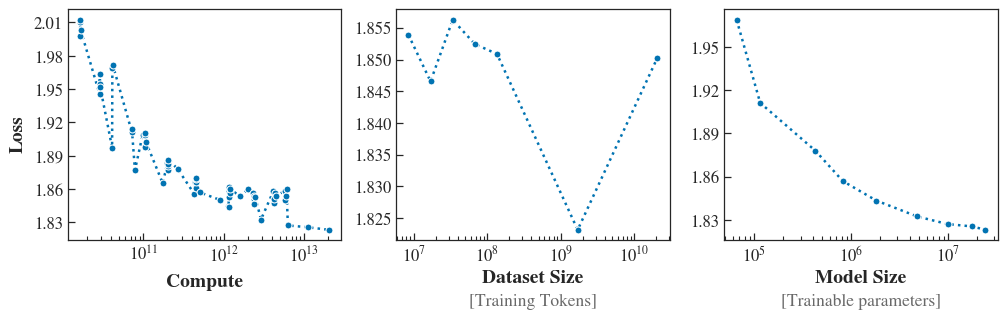

In [226]:
analv2.plotting_v2.fontsize_ticks = 12
analv2.plotting_v2.fontsize_axes_labels = 14

fig_cdp, axes = plt.subplots(1, 3, figsize=(12, 3))
ax_c, ax_d, ax_p = axes

# Set y-axis label on the left-most graph since all y-axes are the same
ax_c.text(
    -0.18, 0.4, "Loss", transform=ax_c.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Compute =====

sns.lineplot(
    ax=ax_c,
    data=df_compute, x="compute", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_c.set_xlabel("")
ax_c.set_ylabel("")
ax_c.set_xscale("log")
ax_c.text(
    0.5, -0.18, "Compute", transform=ax_c.transAxes,
    ha="center", va='center', fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Dataset Size =====

sns.lineplot(
    ax=ax_d,
    data=df_dataset_size, x="num_train_tokens", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.set_xscale("log")
ax_d.text(
    0.5, -0.18, "Dataset Size", transform=ax_d.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_d.text(
    0.5, -0.28, "[Training Tokens]", transform=ax_d.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

# ===== Loss vs. Model Size =====

sns.lineplot(
    ax=ax_p,
    data=df_model_size, x="num_params", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_p.set_xlabel("")
ax_p.set_ylabel("")
ax_p.set_xscale("log")
ax_p.text(
    0.5, -0.18, "Model Size", transform=ax_p.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_p.text(
    0.5, -0.28, "[Trainable parameters]", transform=ax_p.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

for ax in axes:
    ax.tick_params(axis='both', labelsize=analv2.plotting_v2.fontsize_ticks)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax_p.yaxis.set_major_locator(MaxNLocator(nbins=6))

plt.show()

## <span style="color:#db7d60">Figure 2</span>

Figure 4 from the kaplan paper

In [227]:
model_names_md_sizes = model_names_all
df_md_sizes = analv2.tables.get_default_df(model_names_md_sizes)
df_md_sizes["compute"] = df_md_sizes["num_params"] * df_md_sizes["batch_size"] * df_md_sizes["iters_saved"]

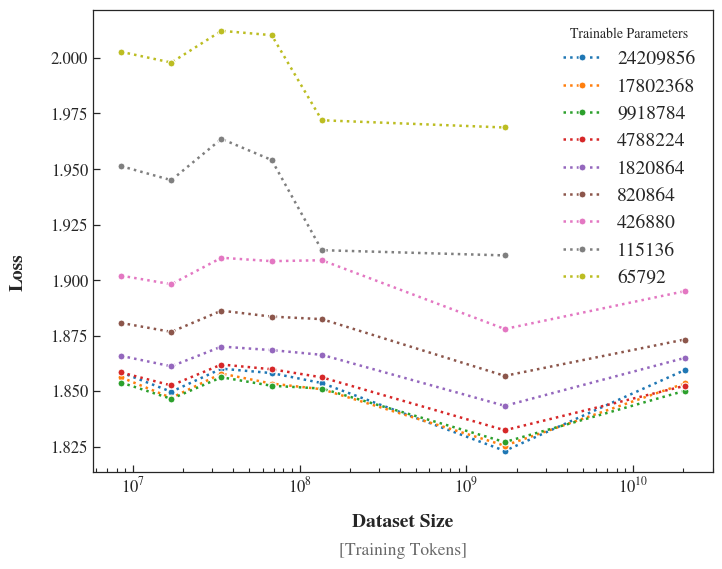

In [228]:
df_md_sizes = df_md_sizes[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_md_sizes["num_params_label"] = df_md_sizes["num_params"].map(lambda x: f"{x/1e6:.0f}M")

order = (df_md_sizes.sort_values("num_params")["num_params"].drop_duplicates().iloc[::-1])

fig_dp_all, axes = plt.subplots(1, 1, figsize=(8, 6))
ax_md = axes

sns.lineplot(
    ax=ax_md,
    data=df_md_sizes, x="num_train_tokens", y="min_saved_val_loss", hue="num_params", hue_order=order,
    palette="tab10", marker="o", estimator=None, linestyle=':'
)
ax_md.set_xlabel("")
ax_md.set_ylabel("")

# y-label
ax_md.text(
    -0.12, 0.4, "Loss", transform=ax_md.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
# x-label
ax_md.text(
    0.5, -0.12, "Dataset Size", transform=ax_md.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_md.text(
    0.5, -0.18, "[Training Tokens]", transform=ax_md.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

ax_md.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.fontsize_legend)
ax_md.set_xscale("log")

plt.xticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.yticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.show()

## <span style="color:#db7d60">Figure 3</span>

Figure 9 from the kaplan paper

In [229]:
model_names_dm_sizes = model_names_all
df_dm_sizes = analv2.tables.get_default_df(model_names_dm_sizes)
df_dm_sizes["compute"] = df_dm_sizes["num_params"] * df_dm_sizes["batch_size"] * df_dm_sizes["iters_saved"]

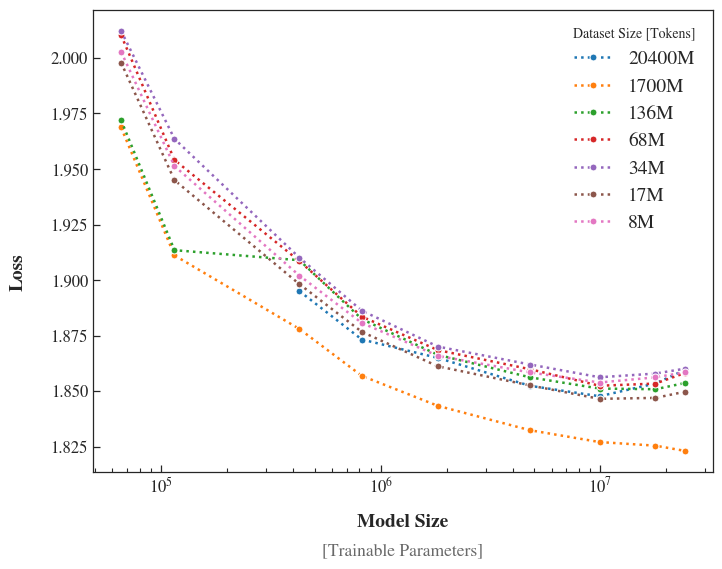

In [230]:
df_dm_sizes = df_dm_sizes[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_dm_sizes["num_params_label"] = df_dm_sizes["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_dm_sizes["num_train_tokens_label"] = df_dm_sizes["num_train_tokens"].map(lambda x: f"{x/1e6:.0f}M")

order = (df_dm_sizes.sort_values("num_train_tokens")["num_train_tokens_label"].drop_duplicates().iloc[::-1])

fig_dp_all, axes = plt.subplots(1, 1, figsize=(8, 6))
ax_dm = axes

sns.lineplot(
    ax=ax_dm,
    data=df_dm_sizes, x="num_params", y="min_saved_val_loss", hue="num_train_tokens_label", hue_order=order,
    palette="tab10", marker="o", estimator=None, linestyle=':'
)
ax_dm.set_xlabel("")
ax_dm.set_ylabel("")

# y-label
ax_dm.text(
    -0.12, 0.4, "Loss", transform=ax_dm.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
# x-label
ax_dm.text(
    0.5, -0.12, "Model Size", transform=ax_dm.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_dm.text(
    0.5, -0.18, "[Trainable Parameters]", transform=ax_dm.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

ax_dm.legend(title="Dataset Size [Tokens]", fontsize=analv2.plotting_v2.fontsize_legend)
ax_dm.set_xscale("log")

plt.xticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.yticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.show()

### Validation loss vs. iterations curve for all dataset sizes

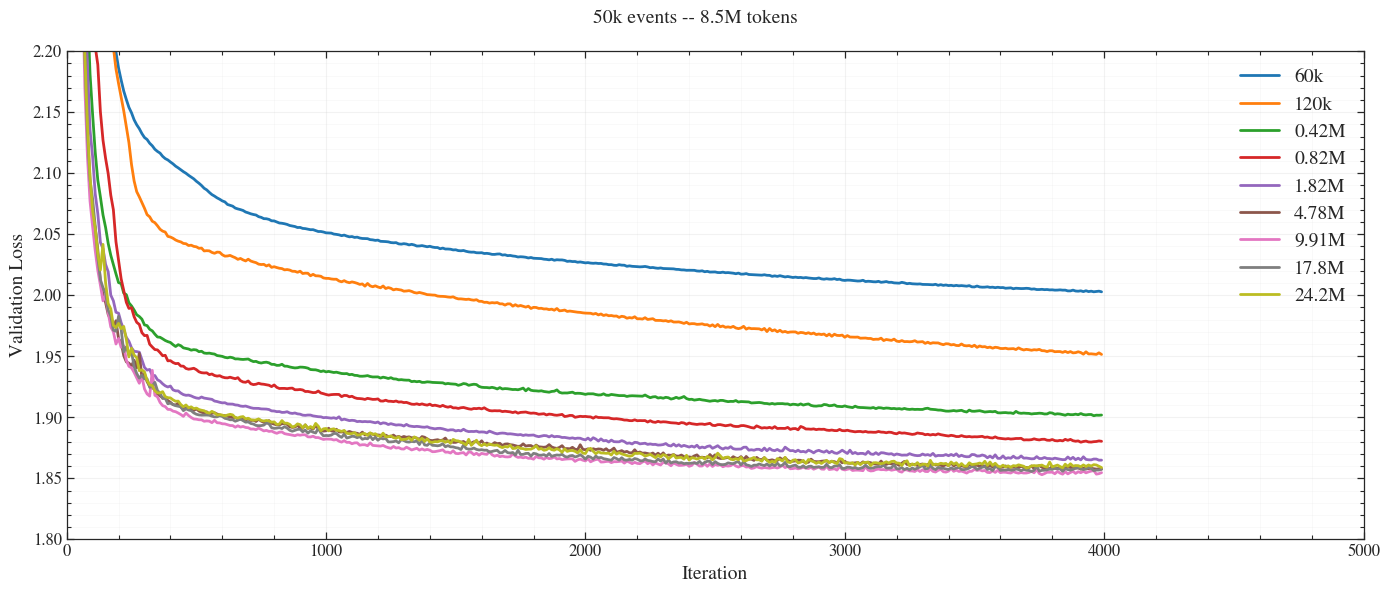

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [231]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_50k_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_50k_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_50k_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_50k_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_50k_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_50k_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_50k_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_50k_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_50k_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,5000), figsize=(14, 6), title='50k events -- 8.5M tokens'
)

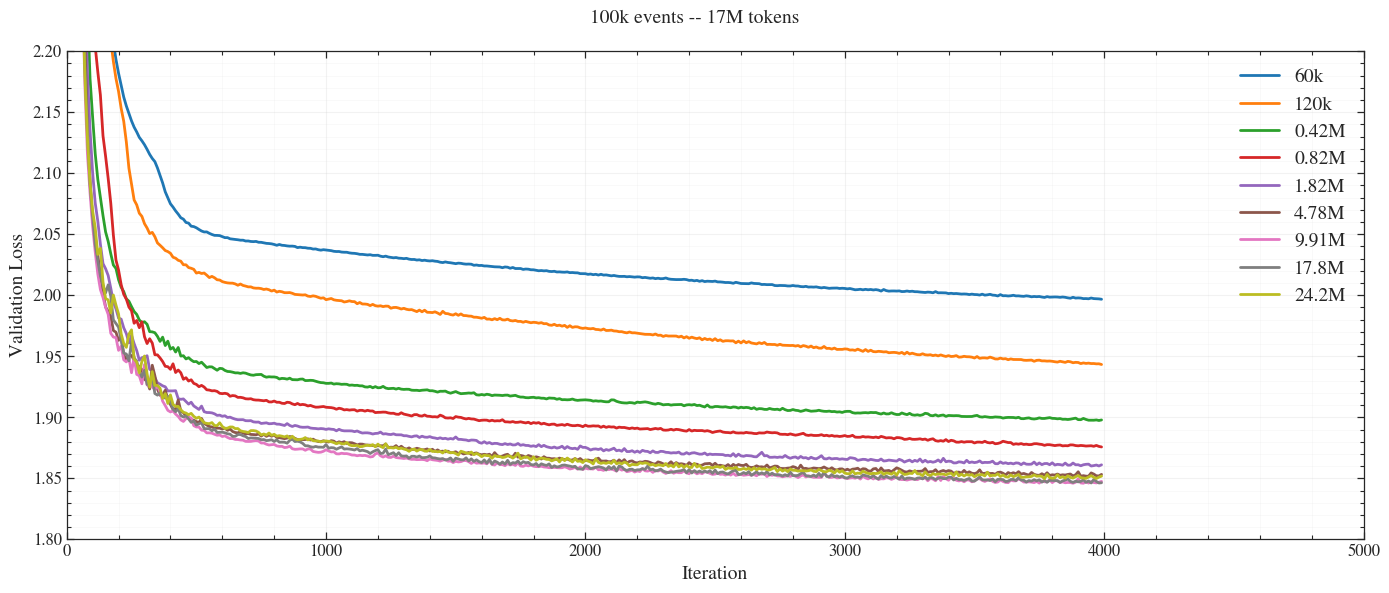

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [232]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_100k_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_100k_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_100k_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_100k_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_100k_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_100k_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_100k_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_100k_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_100k_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,5000), figsize=(14, 6), title='100k events -- 17M tokens'
)

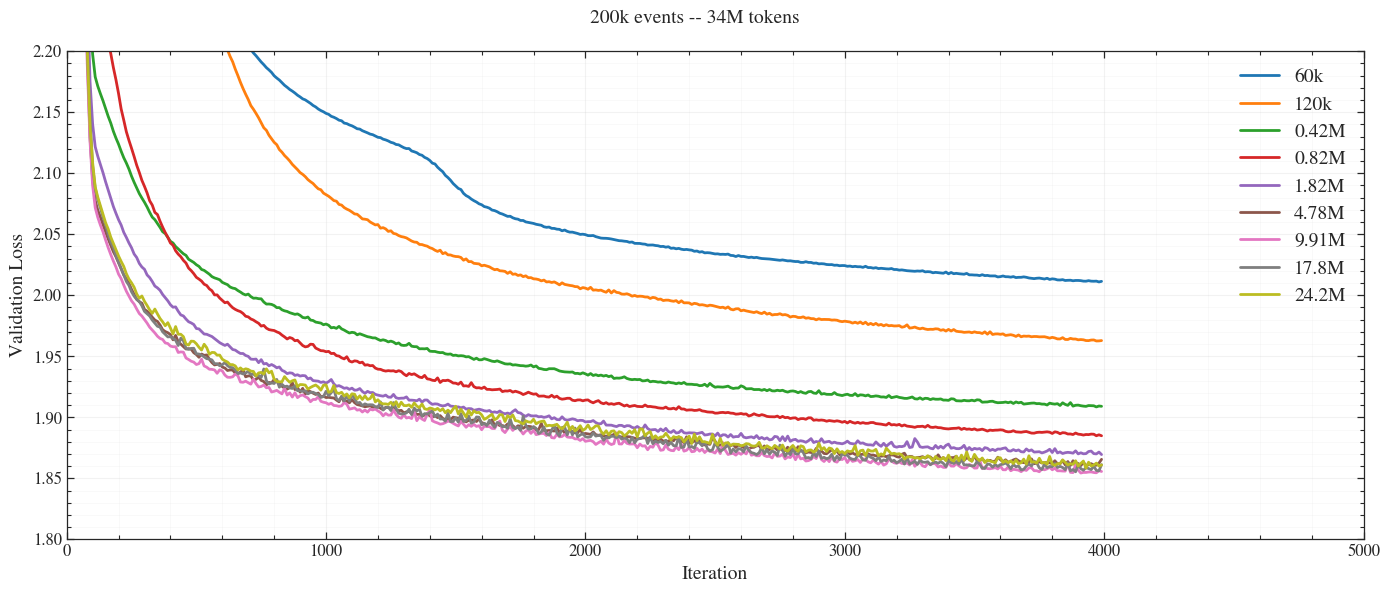

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [233]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_200k_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_200k_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_200k_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_200k_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_200k_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_200k_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_200k_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_200k_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_200k_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,5000), figsize=(14, 6), title='200k events -- 34M tokens'
)

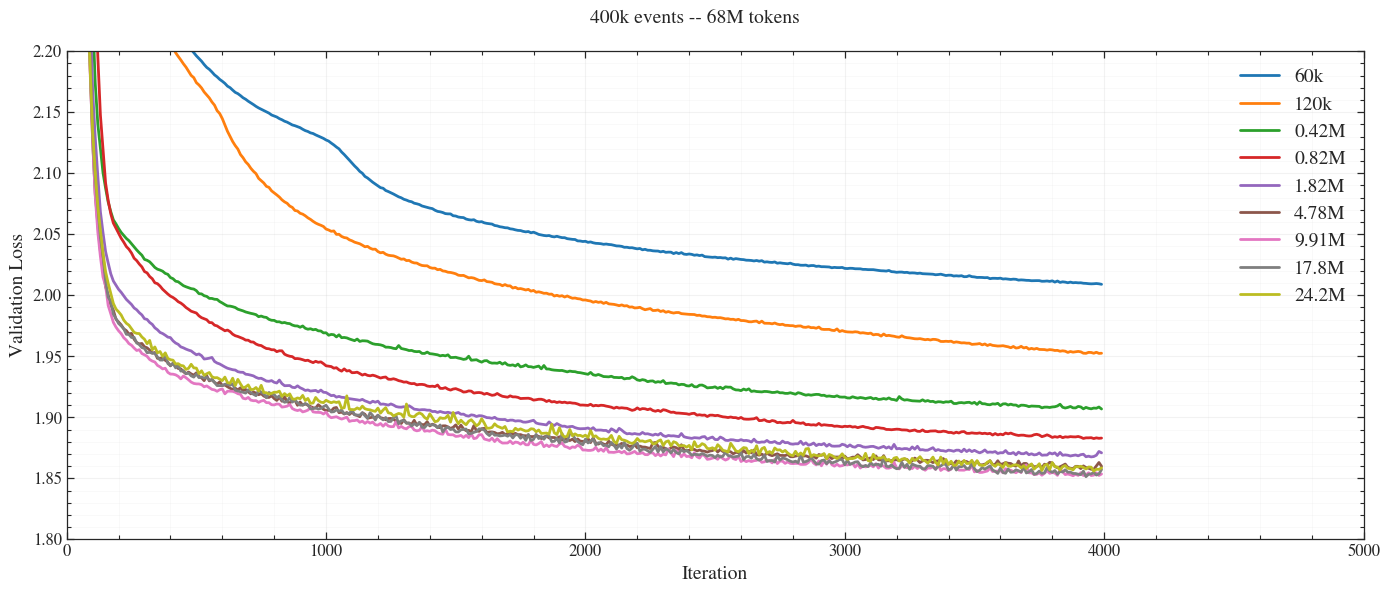

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [234]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_400k_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_400k_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_400k_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_400k_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_400k_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_400k_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_400k_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_400k_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_400k_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,5000), figsize=(14, 6), title='400k events -- 68M tokens'
)

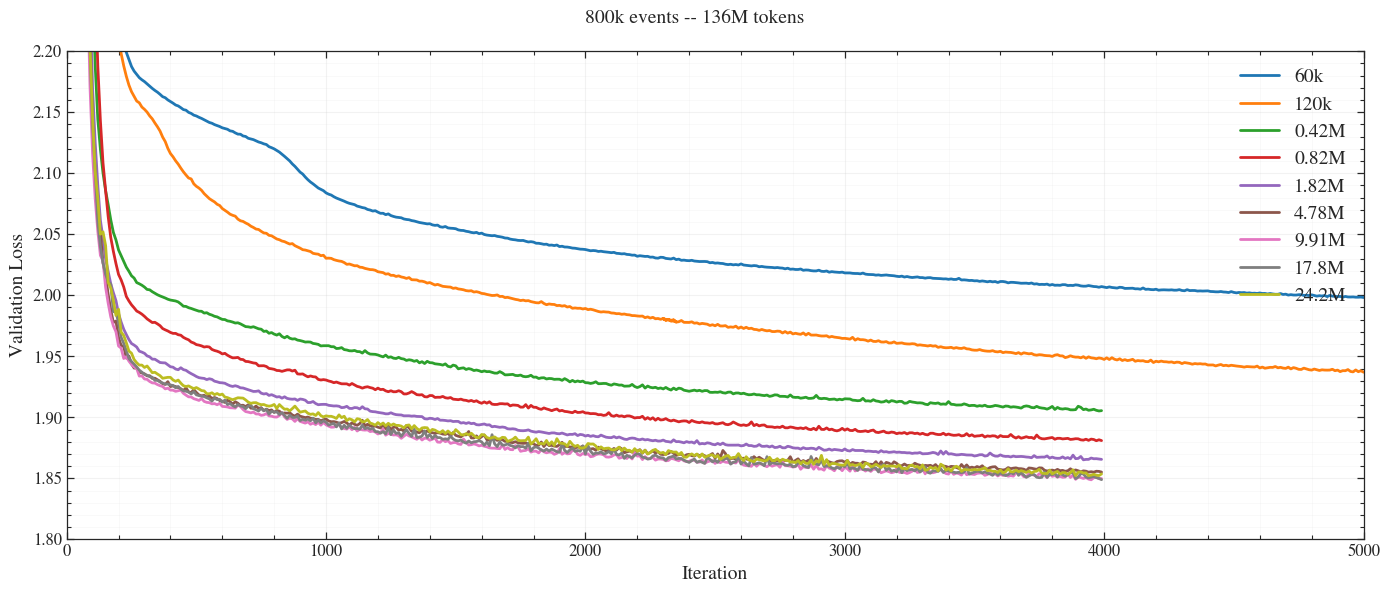

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [235]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_800k_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_800k_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_800k_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_800k_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_800k_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_800k_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_800k_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_800k_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_800k_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,5000), figsize=(14, 6), title='800k events -- 136M tokens'
)

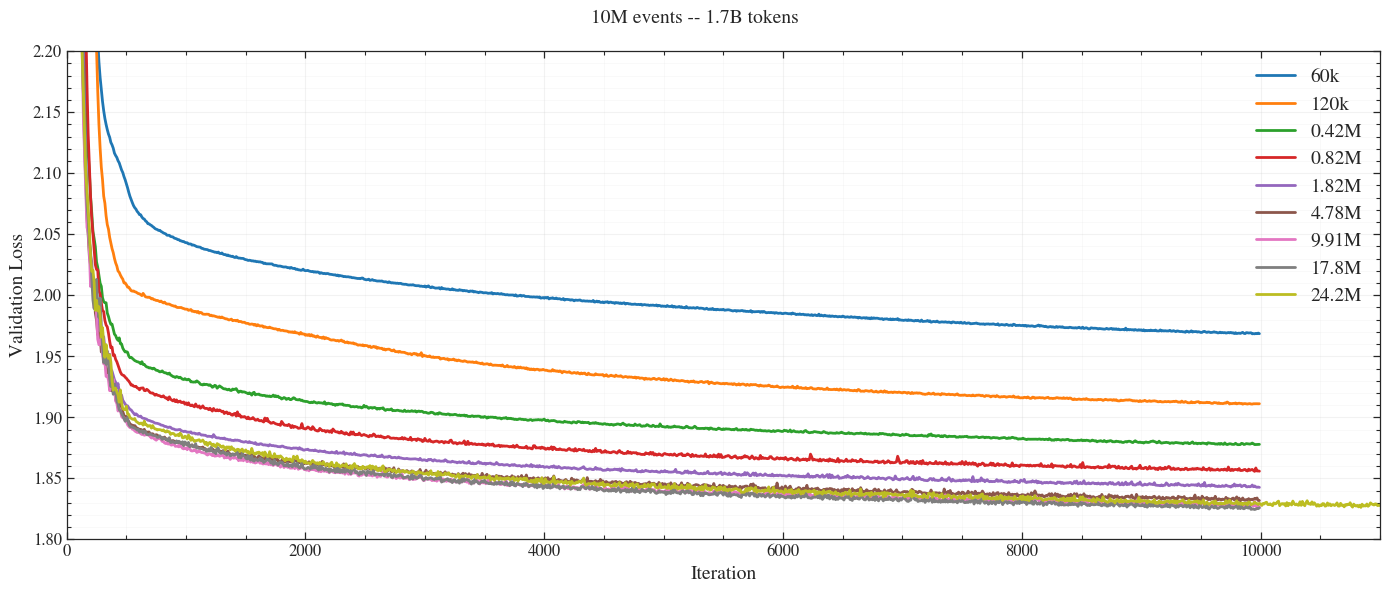

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [236]:
model_names_and_labels = {
    'model_exp14_scaling_law_1_10M_lr1_tp9': '60k',
    'model_exp14_scaling_law_1_10M_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_10M_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_10M_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_10M_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_10M_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_10M_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_10M_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_10M_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,11000), figsize=(14, 6), title='10M events -- 1.7B tokens'
)

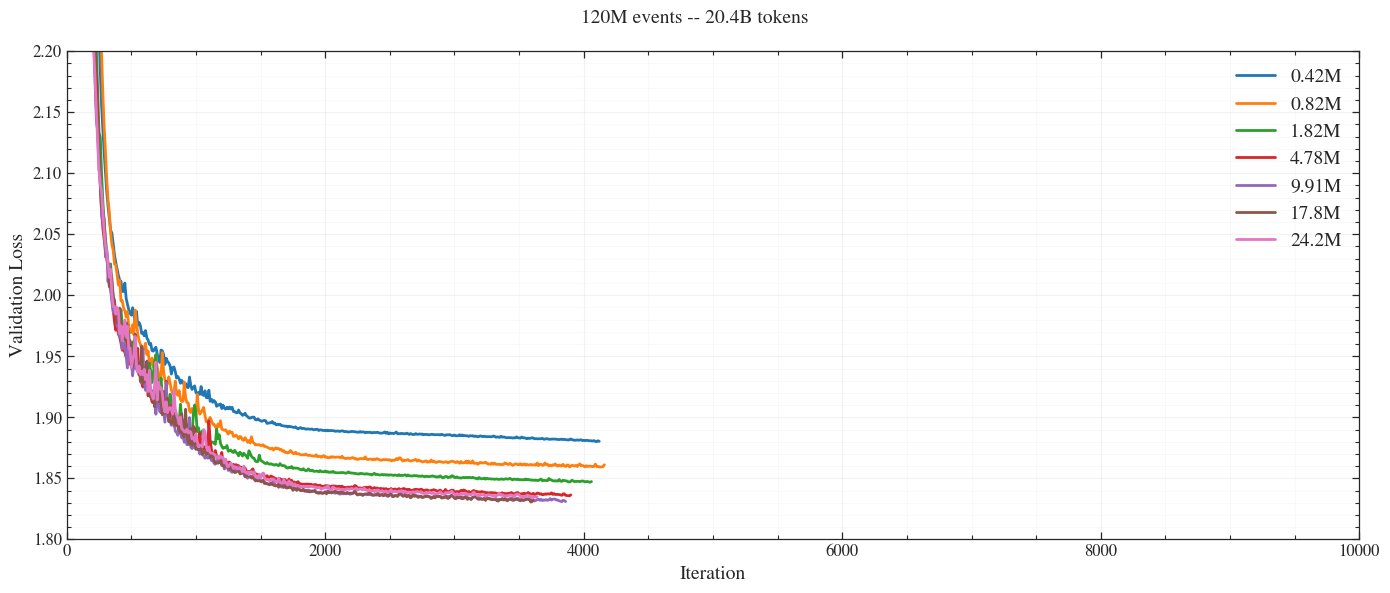

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [239]:
model_names_and_labels = {
    # 'model_exp14_scaling_law_1_120M_lr1_tp9': '60k',
    # 'model_exp14_scaling_law_1_120M_lr1_tp8': '120k',
    'model_exp14_scaling_law_1_120M_lr1_tp1': '0.42M',
    'model_exp14_scaling_law_1_120M_lr1_tp2': '0.82M',
    'model_exp14_scaling_law_1_120M_lr1_tp3': '1.82M',
    'model_exp14_scaling_law_1_120M_lr1_tp4': '4.78M',
    'model_exp14_scaling_law_1_120M_lr1_tp5': '9.91M',
    'model_exp14_scaling_law_1_120M_lr1_tp6': '17.8M',
    'model_exp14_scaling_law_1_120M_lr1_tp7': '24.2M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.8, 2.2), x_lim=(0,10000), figsize=(14, 6), title='120M events -- 20.4B tokens'
)